# Lector de Shapefile — Manzanas EPSEL (Datathon SUNASS 2026)


## 1. Instalar geopandas

In [ ]:
!pip install -q geopandas mapclassify folium

## 2. Montar Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

## 3. Localizar el shapefile

Ajusta `CARPETA` si tu ruta es distinta. Por defecto: `Mi unidad/SUNASS`.

In [ ]:
import os

CARPETA = '/content/drive/MyDrive/SUNASS'
SHP = os.path.join(CARPETA, 'SHP.shp')

print('Archivos en la carpeta:')
for f in sorted(os.listdir(CARPETA)):
    print('  ', f)

assert os.path.exists(SHP), 'No encuentro SHP.shp — revisa la variable CARPETA'
print('\n Shapefile encontrado:', SHP)

Archivos en la carpeta:
   SHP.cpg
   SHP.dbf
   SHP.prj
   SHP.sbn
   SHP.sbx
   SHP.shp
   SHP.shp.xml
   SHP.shx

✅ Shapefile encontrado: /content/drive/MyDrive/SUNASS/SHP.shp


## 4. Cargar y resumir

`geopandas` lee automáticamente el `.dbf`, `.prj`, `.shx`, etc.

In [ ]:
import geopandas as gpd

gdf = gpd.read_file(SHP)

print('========== RESUMEN ==========')
print('Registros (manzanas):', len(gdf))
print('CRS original        :', gdf.crs)        # EPSG:3857 (Web Mercator)
print('Tipo de geometría   :', gdf.geom_type.unique())
print('Columnas            :', list(gdf.columns))

========== RESUMEN ==========
Registros (manzanas): 776
CRS original        : EPSG:3857
Tipo de geometría   : ['Polygon']
Columnas            : ['sector', 'provincia', 'localidad', 'manzana', 'codante', 'SHAPE__Len', 'SHAPE__Are', 'created_us', 'created_da', 'last_edite', 'last_edi_1', 'geometry']


In [ ]:
import geopandas as gpd

In [ ]:
manzanas = gpd.read_file('/content/drive/MyDrive/SUNASS/SHP.shp')
redes = gpd.read_file('/content/drive/MyDrive/datos-epsel/REDES PRIMARIAS/REDES_PRIMARIAS.shp')

print('manzanas',manzanas.crs)
print('redes',redes.crs)

manzanas EPSG:3857
redes EPSG:3857


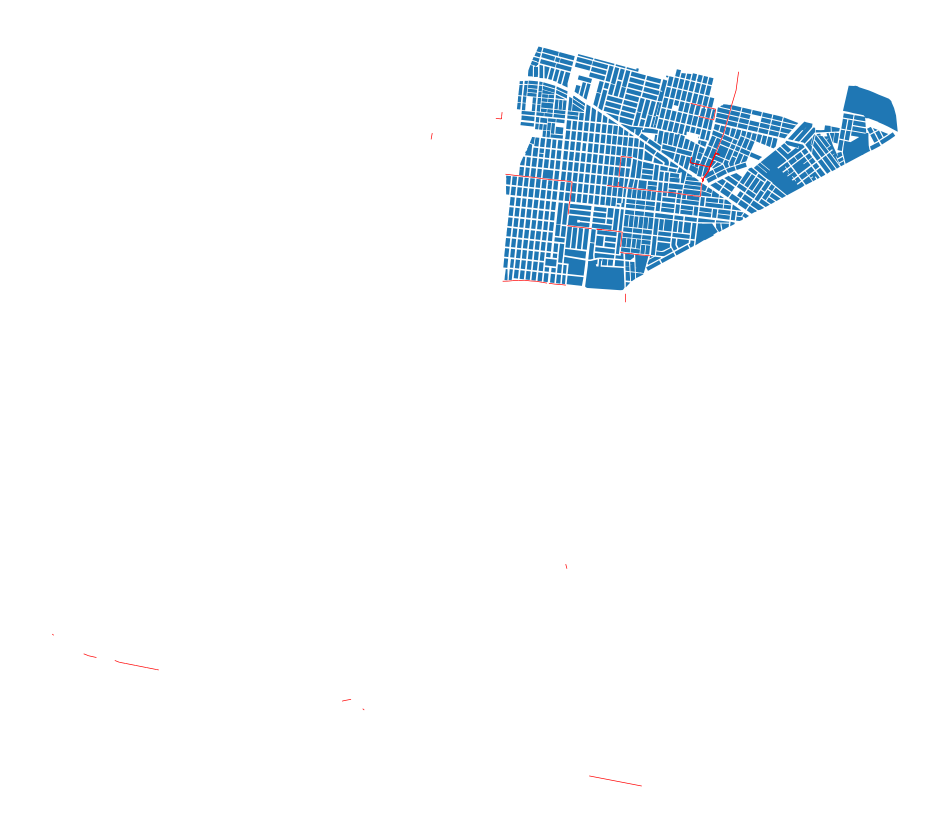

In [ ]:
import matplotlib.pyplot as plt

# ax = gdf.plot(figsize=(10, 10), edgecolor='#333', facecolor='#cfe3f7', linewidth=0.3)
# ax.set_title(f"Manzanas EPSEL — Sector {gdf['sector'].iloc[0]} (Chiclayo) · {len(gdf)} polígonos")
# ax.set_axis_off()

fix , ax = plt.subplots(figsize=(12,12))
#Manzanas
manzanas.plot(ax=ax, color='#1f77b4', linewidth=0.5)
#redes
redes.query('facilityid in @list_redes').plot(ax=ax, color='red', linewidth=0.5)

ax.set_axis_off()
plt.show()


In [ ]:
manzanas_redes = gpd.sjoin_nearest(manzanas, redes, how='left', max_distance=200)

In [ ]:
manzanas_redes.shape

(890, 64)

In [ ]:
manzanas_redes.head()

,sector,provincia,localidad,manzana,codante,SHAPE__Len_left,SHAPE__Are,created_us_left,created_da_left,last_edite_left,last_edi_1_left,geometry,index_right,facilityid,mainshape,diameter,material,primarynet,networktyp,matrix,watertype,frommh,tomh,sumflow,bedtype,exposed,visitable,linedyear,linertype,downelev,upelev,slope,reallength,enabled,activeflag,ownedby,maintby,lastupdate,lasteditor,lastrevdat,condition,obstructio,lastrepair,repairs,installdat,installer,estimatedr,expedientc,sapcode,district,centercost,terraintyp,changereas,changedocu,installati,montante,nomptar,ptofinalde,networkloc,SHAPE__Len_right,created_us_right,created_da_right,last_edite_right,last_edi_1_right
0,09,01,01,01.01.09.001,01.01.09.001,254.862247,2429.453279,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13,"POLYGON Z ((-8887864.234 -754451.679 0, -88878...",1075.0,FID_047391,Desconocido,400.0,CSN,1.0,Desconocido,None,Desconocido,None,None,0.0,Desconocido,No,No,None,Desconocido,0.0,0.0,0.0,44.00,0.0,0.0,Lam1,Lam1,NaT,None,NaT,Desconocido,0,NaT,0.0,NaT,Desconocido,NaT,None,None,140105,None,Desconocido,None,None,0.0,0.0,Desconocido,Desconocido,Via Publica,51.784864,mijail.carpio,2025-10-13,usuario.epsel04,2025-10-23
1,09,01,01,01.01.09.002,01.01.09.015,262.785606,3041.454487,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13,"POLYGON Z ((-8887844.363 -754553.367 0, -88878...",1076.0,FID_047393,Desconocido,400.0,CSN,1.0,Desconocido,None,Desconocido,None,None,0.0,Desconocido,No,No,None,Desconocido,0.0,0.0,0.0,49.75,0.0,0.0,Lam1,Lam1,NaT,None,NaT,Desconocido,0,NaT,0.0,NaT,Desconocido,NaT,None,None,140105,None,Desconocido,None,None,0.0,0.0,Desconocido,Desconocido,Via Publica,44.227968,mijail.carpio,2025-10-13,usuario.epsel04,2025-10-23
2,09,01,01,01.01.09.003,01.01.09.017,242.432781,3276.280541,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13,"POLYGON Z ((-8887764.609 -754530.186 0, -88877...",540.0,FID_047395,Desconocido,400.0,CSN,1.0,Desconocido,None,Desconocido,None,None,0.0,Desconocido,No,No,None,Desconocido,0.0,0.0,0.0,57.50,0.0,0.0,Lam1,Lam1,NaT,None,NaT,Desconocido,0,NaT,0.0,NaT,Desconocido,NaT,None,None,140105,None,Desconocido,None,None,0.0,0.0,Desconocido,Desconocido,Via Publica,54.553418,mijail.carpio,2025-10-13,usuario.epsel04,2025-10-23
3,09,01,01,01.01.09.004,01.01.09.031,243.341586,3286.917782,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13,"POLYGON Z ((-8887708.453 -754536.262 0, -88877...",896.0,FID_050635,Desconocido,400.0,CSN,1.0,Desconocido,None,Desconocido,None,None,0.0,Desconocido,No,No,None,Desconocido,0.0,0.0,0.0,56.10,1.0,1.0,Lam1,Lam1,NaT,None,NaT,Desconocido,0,NaT,0.0,NaT,Desconocido,NaT,None,None,140101,None,Desconocido,Carta,None,0.0,0.0,Desconocido,Desconocido,Via Publica,114.576238,mijail.carpio,2025-10-13,usuario.epsel04,2025-10-23
4,09,01,01,01.01.09.005,01.01.09.033,243.594591,3296.129144,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13,"POLYGON Z ((-8887652.492 -754544.242 0, -88876...",896.0,FID_050635,Desconocido,400.0,CSN,1.0,Desconocido,None,Desconocido,None,None,0.0,Desconocido,No,No,None,Desconocido,0.0,0.0,0.0,56.10,1.0,1.0,Lam1,Lam1,NaT,None,NaT,Desconocido,0,NaT,0.0,NaT,Desconocido,NaT,None,None,140101,None,Desconocido,Carta,None,0.0,0.0,Desconocido,Desconocido,Via Publica,114.576238,mijail.carpio,2025-10-13,usuario.epsel04,2025-10-23


In [ ]:
manzanas_redes.facilityid.to_list()

['FID_047391',
 'FID_047393',
 'FID_047395',
 'FID_050635',
 'FID_050635',
 'FID_047401',
 'FID_047413',
 'FID_047411',
 'FID_047407',
 'FID_047405',
 'FID_047403',
 'FID_047403',
 'FID_047403',
 'FID_047403',
 'FID_047405',
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 'FID_046043',
 'FID_046043',
 'FID_046043',
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 nan,
 'FID_045371',
 'FID_045375',
 'FID_045375',
 'FID_046071',
 'FID_046069',
 'FID_046067',
 'FID_045973',
 'FID_047979',
 'FID_046015',
 'FID_047979',
 'FID_046019',
 'FID_046019',
 'FID_046019',
 'FID_046019',
 'FID_045977',
 'FID_045977',
 'FID_045977',
 'FID_045977',
 'FID_046077',
 'FID_045977',
 'FID_046077',
 'FID_046079',
 'FID_045971',
 'FID_045979',
 'FID_045979',
 'FID_046077',
 'FID_045977',
 'FID_045977',
 'FID_045977',
 'FID_045977',
 'FID_045977',
 'FID_046021',
 'FID_046021',
 'FID_046021',
 'FID_045975',
 'FID_045973',
 'FID_045973',
 'FID_046065',
 'FID_046067',
 'FID_046069',
 'FI

In [ ]:
list_redes = manzanas_redes.facilityid.to_list()

In [ ]:
print(gdf.crs)

EPSG:3857


In [ ]:
from IPython.display import display

display(gdf.head(10))

NameError: name 'gdf' is not defined

In [ ]:
list(gdf.columns)

['facilityid',
 'mainshape',
 'diameter',
 'material',
 'primarynet',
 'networktyp',
 'matrix',
 'watertype',
 'frommh',
 'tomh',
 'sumflow',
 'bedtype',
 'exposed',
 'visitable',
 'linedyear',
 'linertype',
 'downelev',
 'upelev',
 'slope',
 'reallength',
 'enabled',
 'activeflag',
 'ownedby',
 'maintby',
 'lastupdate',
 'lasteditor',
 'lastrevdat',
 'condition',
 'obstructio',
 'lastrepair',
 'repairs',
 'installdat',
 'installer',
 'estimatedr',
 'expedientc',
 'sapcode',
 'district',
 'centercost',
 'terraintyp',
 'changereas',
 'changedocu',
 'installati',
 'montante',
 'nomptar',
 'ptofinalde',
 'networkloc',
 'SHAPE__Len',
 'created_us',
 'created_da',
 'last_edite',
 'last_edi_1',
 'geometry']

In [ ]:
gdf.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 52 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   facilityid  1773 non-null   object        
 1   mainshape   1791 non-null   object        
 2   diameter    1793 non-null   float64       
 3   material    1793 non-null   object        
 4   primarynet  1793 non-null   int32         
 5   networktyp  1793 non-null   object        
 6   matrix      0 non-null      object        
 7   watertype   1793 non-null   object        
 8   frommh      0 non-null      object        
 9   tomh        0 non-null      object        
 10  sumflow     1793 non-null   float64       
 11  bedtype     1793 non-null   object        
 12  exposed     1793 non-null   object        
 13  visitable   1793 non-null   object        
 14  linedyear   0 non-null      object        
 15  linertype   1793 non-null   object        
 16  downelev    1793

In [ ]:
print(gdf.geom_type.value_counts())

LineString    1793
Name: count, dtype: int64


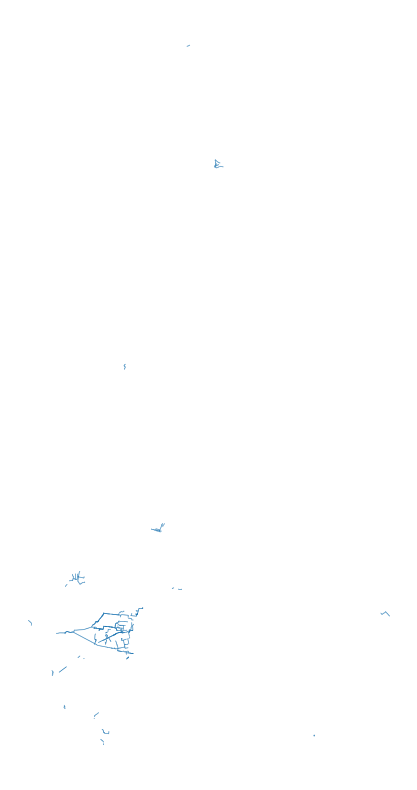

In [ ]:
import matplotlib.pyplot as plt

fix , ax = plt.subplots(figsize=(10,10))
gdf.plot(ax=ax, color='#1f77b4', linewidth=0.5)
ax.set_axis_off()
plt.show()

# ax = gdf.plot(figsize=(10, 10), edgecolor='#333', facecolor='#cfe3f7', linewidth=0.3)
# ax.set_title(f"{gdf['sector'].iloc[0]} (Chiclayo) · {len(gdf)} polígonos")
# ax.set_axis_off()
# plt.show()

In [ ]:
from pandas import pandas as pd

In [ ]:
pd.set_option('display.max_columns', None)

## 5. Ver los atributos (tabla)

In [ ]:
from IPython.display import display

display(gdf.drop(columns='geometry').head(10))

,sector,provincia,localidad,manzana,codante,SHAPE__Len,SHAPE__Are,created_us,created_da,last_edite,last_edi_1
0,09,01,01,01.01.09.001,01.01.09.001,254.862247,2429.453279,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
1,09,01,01,01.01.09.002,01.01.09.015,262.785606,3041.454487,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
2,09,01,01,01.01.09.003,01.01.09.017,242.432781,3276.280541,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
3,09,01,01,01.01.09.004,01.01.09.031,243.341586,3286.917782,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
4,09,01,01,01.01.09.005,01.01.09.033,243.594591,3296.129144,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
5,09,01,01,01.01.09.006,01.01.09.047,244.125725,3303.837313,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
6,09,01,01,01.01.09.007,01.01.09.049,245.728714,3373.630635,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
7,09,01,01,01.01.09.008,01.01.09.065,246.291779,3361.842746,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
8,09,01,01,01.01.09.009,01.01.09.067,250.238414,3472.776732,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13
9,09,01,01,01.01.09.010,01.01.09.079,247.134117,3353.350564,mijail.carpio,2025-10-13,mijail.carpio,2025-10-13


## 6. Reproyectar a UTM 17S (EPSG:32717) y calcular áreas reales

Las áreas del `.dbf` original están en Web Mercator (~1.4% infladas). UTM 17S da metros correctos.

In [ ]:
gdf_utm = gdf.to_crs(epsg=32717)
gdf_utm['area_m2'] = gdf_utm.geometry.area

print('Área total      (m²):', round(gdf_utm['area_m2'].sum(), 1))
print('Área media/mz   (m²):', round(gdf_utm['area_m2'].mean(), 1))
print('Área mín / máx  (m²):', round(gdf_utm['area_m2'].min(), 1), '/', round(gdf_utm['area_m2'].max(), 1))

Área total      (m²): 3203254.9
Área total      (km²): 3.203
Área media/mz   (m²): 4127.9
Área mín / máx  (m²): 84.0 / 120503.0


## 7. Valores únicos de los campos clave

In [ ]:
for col in ['sector', 'provincia', 'localidad']:
    print(f'{col:10s}:', sorted(gdf[col].unique()))

print('\nmanzanas distintas :', gdf['manzana'].nunique())
print('codante distintos  :', gdf['codante'].nunique())

sector    : ['09']
provincia : ['01']
localidad : ['01']

manzanas distintas : 772
codante distintos  : 758
creado por         : {'mijail.carpio': 775, 'usuario.epsel05': 1}


## 8. Mapa estático

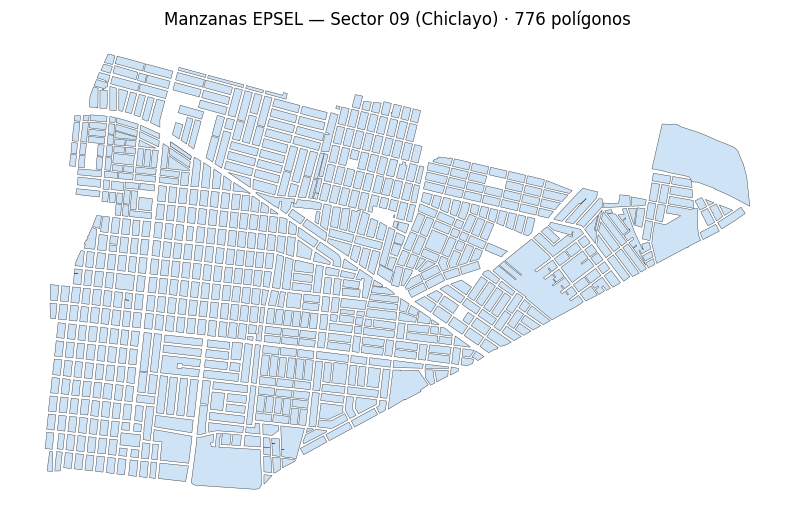

In [ ]:
import matplotlib.pyplot as plt

# ax = gdf.plot(figsize=(10, 10), edgecolor='#333', facecolor='#cfe3f7', linewidth=0.3)
# ax.set_title(f"Manzanas EPSEL — Sector {gdf['sector'].iloc[0]} (Chiclayo) · {len(gdf)} polígonos")
# ax.set_axis_off()

fix , ax = plt.subplots(figsize=(10,10))
#Manzanas

gdf.plot(ax=ax, color='#1f77b4', linewidth=0.5)
ax.set_title(f"Manzanas EPSEL — Sector {gdf['sector'].iloc[0]} (Chiclayo) · {len(gdf)} polígonos")

ax.set_axis_off()
plt.show()

plt.show()



## 9. Mapa interactivo sobre OpenStreetMap

Útil para la presentación / dashboard. Coloreado por área; tooltip con manzana y codante.

In [ ]:
gdf_wgs = gdf.to_crs(epsg=4326)
gdf_wgs['area_m2'] = gdf_utm['area_m2'].values

m2 = gdf.to_crs(epsg=4326).explore(
    color='#2176c4',                                  # mismo color para todas
    style_kwds={'fillOpacity': 0.55, 'weight': 0.8, 'color': '#0d3d6b'},
    tooltip=['manzana', 'codante'],
    tiles='OpenStreetMap',
)
m2

In [ ]:
# gdf.to_parquet('/content/drive/MyDrive/SUNASS/manzanas_epsel.parquet')